# Rank Percentile Score Distributions

Five-panel figure comparing **raw docking scores** (left column) against **Guild-standardised
rank-percentile scores** (right column) across the five pose sources: **Vina**, **GNINA**,
**KarmaDock**, **DiffDock**, and **Boltz-2**.

- Each method is assigned a consistent colour.
- All non-decoy compounds are shown in the method colour (categories pooled).
- Decoys are shown as a muted grey background KDE for reference.
- DiffDock and Boltz-2 plot the Vina-rescore ΔG that actually enters the score
  (`vina_rescore_diffdock_score` / `vina_rescore_boltz_score`), not the native pose
  confidence -- see `20b3c50` and R2-3. The rank-percentile column is bounded-KDE
  estimated (`kde_curve_bounded`), so it stays inside [0, 1] and integrates to 1.
- The right column plots `1 - rp_*`, so higher reads as better -- the stored `rp_*`
  columns are 0 = best throughout guild (see `notebooks/analysis/README.md`); the same
  inversion `score_comparison.ipynb` applies to Figure 3, and
  `build_rank_percentile_schematic.py` applies to the Supplementary Text 3 schematic, so
  all three figures share one on-axis convention.
- Source: `notebooks/analysis/data/guild_scores.txt` (the 3-target rerun -- see
  `notebooks/analysis/README.md` for why this replaced the original many-target file).</cell id="0">


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from legacy_columns import LEGACY_RENAME

from guild.constants.guild import (
    BOLTZ_AFFINITY_PREFIX,
    BOLTZ_PREFIX,
    DIFFDOCK_PREFIX,
    GNINA_PREFIX,
    KARMADOCK_PREFIX,
    PROTEIN_CONF_ID,
    VINA_PREFIX,
    VINA_RESCORE_BOLTZ_PREFIX,
    VINA_RESCORE_DIFFDOCK_PREFIX,
)
from guild.tools.scores import compute_rank_percentile_scores, is_physical_score

# ── Paths ────────────────────────────────────────────────────────────────────
# Figure 2 is rebuilt from the 3-target rerun (guild_scores.txt), which replaces
# the many-target case-study file this notebook used to read -- see
# notebooks/analysis/README.md. Override with the GUILD_FIGURES_DATA_DIR env var
# or by editing DATA_DIR, mirroring --data in
# notebooks/analysis/reviewer_response/reproduce_response_analyses.py.
DATA_DIR  = Path(os.environ.get("GUILD_FIGURES_DATA_DIR", "data"))
DATA_FILE = DATA_DIR / "guild_scores.txt"
# Mirrors DATA_DIR above: override with GUILD_FIGURES_OUT_DIR so a real render can be
# written somewhere durable instead of this scratch default.
OUT_DIR   = os.environ.get("GUILD_FIGURES_OUT_DIR", "np_synthetic_comparison/guild_figures")
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE, sep="\t")
df = df.rename(columns=LEGACY_RENAME)

# "native" rows are the co-crystallised ligand itself, scored at its one true
# pose -- not part of the decoy/binder distributions this figure compares.
n_native = int((df["ligand_category"] == "native").sum())
df = df[df["ligand_category"] != "native"].copy()
n_targets = df["protein_config_id"].str.split("-").str[0].nunique()
print(f"Rows: {len(df)}  ({n_targets} targets; dropped {n_native} native rows)")
print(df["ligand_category"].value_counts())

# ── Non-physical raw scores ──────────────────────────────────────────────────
# A Vina-family energy has to be negative (a favourable binding free energy) to
# be a real result at all -- guild.tools.scores.is_physical_score additionally
# guards the -20 kcal/mol tail, but its [-20, 0] range is boundary-inclusive,
# which is the right call for genuine continuous ΔG values but not here:
# vina_rescore_diffdock_score has a 51-row cluster sitting at *exactly* 0.0
# (30% of it -- confirmed not present in vina_score, gnina_score or
# vina_rescore_boltz_score, so this is specific to this track), which reads as
# a rescoring-failure sentinel rather than a genuine result, on top of 83 rows
# that are positive outright. The reply to R2-4 counts both as failures, so
# both are nulled here -- not dropped, so the rank percentiles below never see
# them either, the same nulling run_guild_scoring(exclude_non_physical=True)
# already offers, just with the boundary drawn strictly at zero for this
# notebook's own physicality check.
def _is_physical_and_negative(value, method_prefix):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return True
    return is_physical_score(value, method_prefix) and value < 0.0


NON_PHYSICAL_CHECK = {
    "vina_score": VINA_PREFIX,
    "gnina_score": GNINA_PREFIX,
    "vina_rescore_diffdock_score": VINA_RESCORE_DIFFDOCK_PREFIX,
    "vina_rescore_boltz_score": VINA_RESCORE_BOLTZ_PREFIX,
}
non_physical_counts = {}
for raw_col, prefix in NON_PHYSICAL_CHECK.items():
    is_bad = ~df[raw_col].apply(lambda v, p=prefix: _is_physical_and_negative(v, p))
    non_physical_counts[raw_col] = int(is_bad.sum())
    df.loc[is_bad, raw_col] = np.nan
print("Non-physical raw scores nulled before ranking (of non-missing values):")
for raw_col, n_bad in non_physical_counts.items():
    n_present = int(df[raw_col].notna().sum()) + n_bad
    pct = 100 * n_bad / n_present if n_present else float("nan")
    print(f"  {raw_col}: {n_bad}/{n_present} ({pct:.1f}%)")

# ── Rank percentile scores, recomputed fresh ─────────────────────────────────
# This rerun predates boltz_affinity_score's ranking (0d36671) and the median
# aggregation default (0e7c959), so any rp_*/rank_*/global_rp_score columns
# already in the file are stale. Recomputed here rather than trusted, using
# every method this figure or its notes reference.
METHODS = [
    VINA_PREFIX, GNINA_PREFIX, KARMADOCK_PREFIX, DIFFDOCK_PREFIX, BOLTZ_PREFIX,
    VINA_RESCORE_DIFFDOCK_PREFIX, VINA_RESCORE_BOLTZ_PREFIX, BOLTZ_AFFINITY_PREFIX,
]
df = compute_rank_percentile_scores(df, methods=METHODS, protein_col=PROTEIN_CONF_ID)

# ── Per-track coverage ────────────────────────────────────────────────────────
# vina_rescore_* tracks are populated only where receptor preparation for that
# pose succeeded, and DiffDock's rescore also loses the non-physical rows just
# above -- print the actual n behind each panel rather than let a gap-free-
# looking density imply full coverage.
print("\nCoverage after nulling non-physical values (non-null raw score / total rows):")
for raw_col in ["vina_score", "gnina_score", "karmadock_score", "diffdock_score",
                "boltz_score", "vina_rescore_diffdock_score", "vina_rescore_boltz_score",
                "boltz_affinity_score"]:
    n_ok = int(df[raw_col].notna().sum())
    print(f"  {raw_col}: {n_ok}/{len(df)} ({100 * n_ok / len(df):.1f}%)")

Rows: 165  (3 targets; dropped 3 native rows)
ligand_category
decoy            150
strong-binder     15
Name: count, dtype: int64
Non-physical raw scores nulled before ranking (of non-missing values):
  vina_score: 0/165 (0.0%)
  gnina_score: 1/165 (0.6%)
  vina_rescore_diffdock_score: 131/165 (79.4%)
  vina_rescore_boltz_score: 1/135 (0.7%)

Coverage after nulling non-physical values (non-null raw score / total rows):
  vina_score: 165/165 (100.0%)
  gnina_score: 164/165 (99.4%)
  karmadock_score: 165/165 (100.0%)
  diffdock_score: 165/165 (100.0%)
  boltz_score: 165/165 (100.0%)
  vina_rescore_diffdock_score: 34/165 (20.6%)
  vina_rescore_boltz_score: 134/165 (81.2%)
  boltz_affinity_score: 165/165 (100.0%)


In [2]:

# ── Palette & method specs ───────────────────────────────────────────────────
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4.0,
    "ytick.major.size": 4.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 150,
})

METHOD_COLOR = {
    "Vina":      "#1f77b4",
    "GNINA":     "#9467bd",
    "KarmaDock": "#8c564b",
    "DiffDock":  "#ff7f0e",
    "Boltz-2":   "#2ca02c",
}
DECOY_COLOR = "#b0b0b0"

# Five pose sources -- the figure now covers what its caption already claimed
# ("across PLBP algorithms"). DiffDock and Boltz-2 plot the Vina-rescore ΔG
# that actually enters the score, not the native pose confidence (that
# distinction, and R2-3, is why 20b3c50 stopped letting the confidences vote).
# The native confidences are reported in `note` below rather than given their
# own rank-percentile column here -- the same treatment gnina_cnn_score
# already gets: visible, but not ranked or voted on. `note` is pre-wrapped with
# explicit newlines rather than relying on matplotlib's Text(wrap=True), which
# wraps against the full figure width, not the local (narrow) axes.
# (raw_col/rp_col are already nulled for non-physical / recomputed fresh in
# cell 1, so no extra per-row filter lambda is needed here any more.)
METHOD_SPECS = [
    {
        "label": "Vina", "raw_col": "vina_score",
        "raw_xlabel": "Vina score (kcal/mol)", "rp_col": "rp_vina_score",
        "note": None,
    },
    {
        "label": "GNINA", "raw_col": "gnina_score",
        "raw_xlabel": "GNINA score (kcal/mol)", "rp_col": "rp_gnina_score",
        "note": None,
    },
    {
        "label": "KarmaDock", "raw_col": "karmadock_score",
        "raw_xlabel": "KarmaDock score", "rp_col": "rp_karmadock_score",
        "note": None,
    },
    {
        "label": "DiffDock", "raw_col": "vina_rescore_diffdock_score",
        "raw_xlabel": "Vina rescore of DiffDock pose (kcal/mol)",
        "rp_col": "rp_vina_rescore_diffdock_score",
        "note": "diffdock_score (native confidence)\nis reported, not ranked or voted",
    },
    {
        "label": "Boltz-2", "raw_col": "vina_rescore_boltz_score",
        "raw_xlabel": "Vina rescore of Boltz-2 pose (kcal/mol)",
        "rp_col": "rp_vina_rescore_boltz_score",
        "note": ("boltz_score (native confidence)\nis reported, not ranked or voted;\n"
                 "boltz_affinity_score also votes\n(median aggregation, see 0d36671)"),
    },
]


Bounded-KDE integral check (np.trapezoid, target 1.0 +/- 1e-2):
  Vina       compounds  0.9968
  Vina       decoys     1.0000
  GNINA      compounds  0.9963
  GNINA      decoys     1.0000
  KarmaDock  compounds  0.9965
  KarmaDock  decoys     1.0000
  DiffDock   compounds  0.9799  (n=3 < 10, not asserted -- too few points)
  DiffDock   decoys     0.9995
  Boltz-2    compounds  0.9966
  Boltz-2    decoys     1.0000


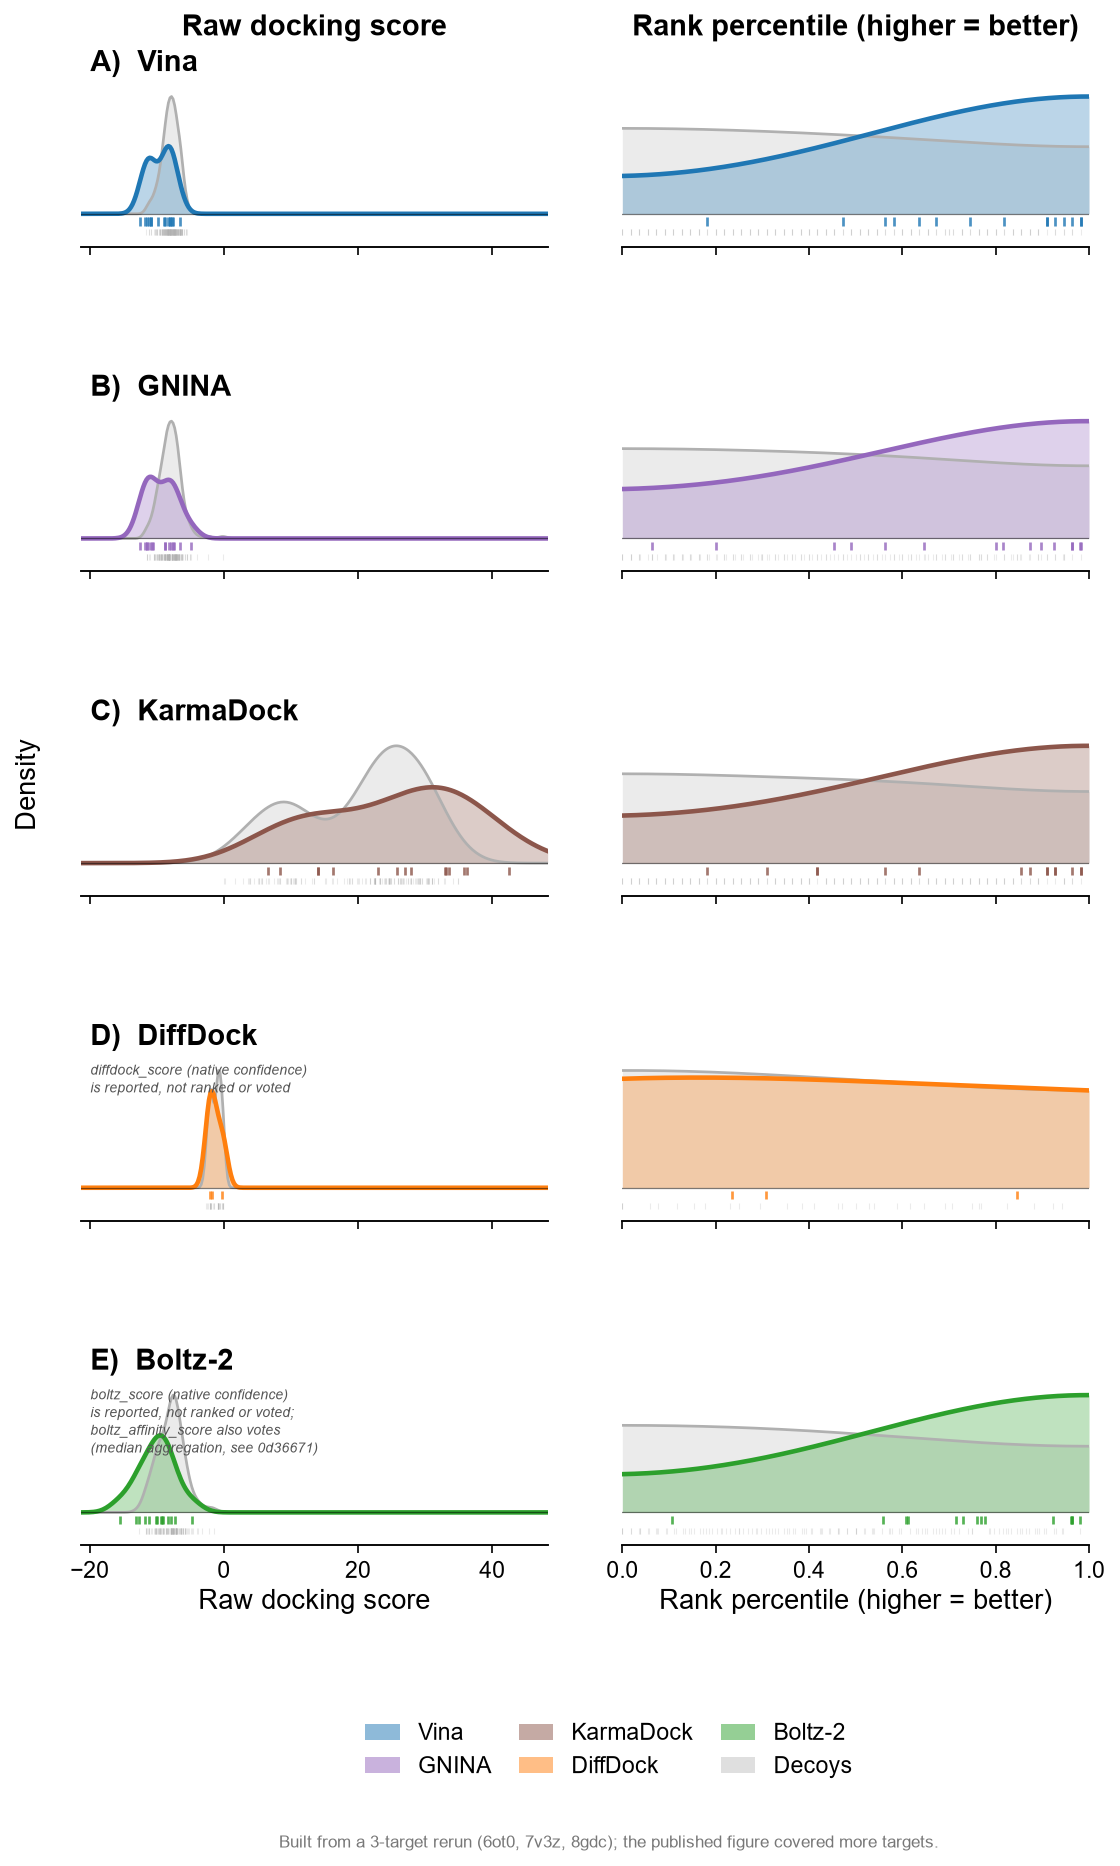

Saved figure_2_score_distributions in C:/Users/antonio/Desktop/guild_publication/review/figures_regenerated
NOTE FOR CAPTION: built from 3 targets (['6ot0', '7v3z', '8gdc']), not the full case study.
NOTE FOR CAPTION [DiffDock]: diffdock_score (native confidence) is reported, not ranked or voted
NOTE FOR CAPTION [Boltz-2]: boltz_score (native confidence) is reported, not ranked or voted; boltz_affinity_score also votes (median aggregation, see 0d36671)


In [3]:
from kde_helpers import kde_curve, kde_curve_bounded
from matplotlib.patches import Patch

N_GRID = 300
COL_TITLES = ["Raw docking score", "Rank percentile (higher = better)"]
PANEL_LABELS = ["A)", "B)", "C)", "D)", "E)"]   # one per row (pose source)
N_ROWS = len(METHOD_SPECS)

# Below this many points, the reflected KDE's own bandwidth estimate is too
# coarse to hit the unit-area target reliably -- a real property of how
# little data survives some panels (DiffDock's binder rescore drops to n=3
# after the non-physical nulling in cell 1), not a bug in kde_curve_bounded,
# so it is reported rather than asserted away below.
MIN_KDE_N = 10

# ═══════════════════════════════════════════════════════════════════════════════
# PASS 0 — find global x-range for the LEFT column (raw scores)
# ═══════════════════════════════════════════════════════════════════════════════
global_xmin_left, global_xmax_left = np.inf, -np.inf

for spec in METHOD_SPECS:
    vals = df[spec["raw_col"]].dropna()
    if len(vals) > 0:
        global_xmin_left = min(global_xmin_left, vals.min())
        global_xmax_left = max(global_xmax_left, vals.max())

pad_left = (global_xmax_left - global_xmin_left) * 0.10
shared_xmin = global_xmin_left - pad_left
shared_xmax = global_xmax_left + pad_left
shared_x_grid = np.linspace(shared_xmin, shared_xmax, N_GRID)

# Right column is rank percentile, bounded to [0, 1] by construction -- the
# grid itself never extends past the valid range (that overshoot was exactly
# what Reviewer 4 saw), and kde_curve_bounded keeps the estimate inside it too.
rp_x_grid = np.linspace(0.0, 1.0, N_GRID)

# ═══════════════════════════════════════════════════════════════════════════════
# PASS 1 — precompute KDEs; track per-ROW max; check the bounded curves integrate to 1
# ═══════════════════════════════════════════════════════════════════════════════
precomp = {}
row_kde_max = [0.0] * N_ROWS
integral_checks = []

for row_idx, spec in enumerate(METHOD_SPECS):
    panels = [(0, spec["raw_col"], spec["raw_xlabel"]), (1, spec["rp_col"], "Rank percentile")]
    for col_idx, (ci, score_col, xlabel) in enumerate(panels):
        sub = df.dropna(subset=[score_col, "ligand_category"])
        decoy_vals     = sub.loc[sub["ligand_category"] == "decoy",  score_col].dropna()
        non_decoy_vals = sub.loc[sub["ligand_category"] != "decoy", score_col].dropna()

        if len(decoy_vals) + len(non_decoy_vals) < 2:
            precomp[(row_idx, ci)] = None
            continue

        if ci == 0:
            x_grid = shared_x_grid
            kde_comp  = kde_curve(non_decoy_vals, x_grid)
            kde_decoy = kde_curve(decoy_vals, x_grid)
        else:
            # Displayed as 1 - rp, so higher reads as better -- the stored rp_* column
            # is 0 = best throughout guild (see notebooks/analysis/README.md). Matches
            # the inversion score_comparison.ipynb applies for Figure 3 and
            # build_rank_percentile_schematic.py applies for the Supp. Text 3 schematic,
            # so a reader sees one convention across all three figures, not the
            # contradiction of a "rank percentile" axis paired with a stored 0 = best
            # value (the confusion behind the Supp. Text 6 discrepancy).
            decoy_vals = 1 - decoy_vals
            non_decoy_vals = 1 - non_decoy_vals
            x_grid = rp_x_grid
            kde_comp  = kde_curve_bounded(non_decoy_vals, x_grid)
            kde_decoy = kde_curve_bounded(decoy_vals, x_grid)
            for label, curve, n in [("compounds", kde_comp, len(non_decoy_vals)),
                                     ("decoys", kde_decoy, len(decoy_vals))]:
                if n < 2:
                    continue
                integral = float(np.trapezoid(curve, x_grid))
                integral_checks.append((spec["label"], label, integral, n))
                if n < MIN_KDE_N:
                    continue
                assert abs(integral - 1.0) < 1e-2, (
                    f"{spec['label']} {label}: bounded KDE integral {integral:.4f} "
                    "is not within 1e-2 of 1.0"
                )

        row_kde_max[row_idx] = max(row_kde_max[row_idx], kde_comp.max(), kde_decoy.max())

        precomp[(row_idx, ci)] = {
            "x_grid": x_grid, "kde_comp": kde_comp, "kde_decoy": kde_decoy,
            "non_decoy_vals": non_decoy_vals, "decoy_vals": decoy_vals,
            "xlabel": xlabel, "method": spec["label"],
        }

print("Bounded-KDE integral check (np.trapezoid, target 1.0 +/- 1e-2):")
for label, series, integral, n in integral_checks:
    flag = "" if n >= MIN_KDE_N else f"  (n={n} < {MIN_KDE_N}, not asserted -- too few points)"
    print(f"  {label:<10s} {series:<10s} {integral:.4f}{flag}")

# ═══════════════════════════════════════════════════════════════════════════════
# PASS 2 — draw N_ROWS×2 figure
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(
    N_ROWS, 2,
    figsize=(8.0, 2.6 * N_ROWS),
    gridspec_kw={"hspace": 0.6, "wspace": 0.16},
)

# Shared x-limits: LEFT column = global raw range; RIGHT column = [0, 1] exactly
# -- no overshoot padding, since a point outside [0, 1] would itself be a bug.
for r in range(N_ROWS):
    axes[r, 0].set_xlim(shared_xmin, shared_xmax)
    axes[r, 1].set_xlim(0.0, 1.0)

for row_idx, spec in enumerate(METHOD_SPECS):
    method = spec["label"]
    color = METHOD_COLOR[method]

    for col_idx in range(2):
        ax   = axes[row_idx, col_idx]
        data = precomp.get((row_idx, col_idx))
        if data is None:
            ax.set_visible(False)
            continue

        x_grid   = data["x_grid"]
        kde_comp = data["kde_comp"]
        kde_decoy= data["kde_decoy"]
        non_decoy_vals = data["non_decoy_vals"]
        decoy_vals     = data["decoy_vals"]

        # Per-panel KDE max so each panel showcases its own shape
        kmax = max(kde_comp.max(), kde_decoy.max())

        # KDEs — decoy background, then compounds on top
        ax.fill_between(x_grid, 0, kde_decoy, color=DECOY_COLOR, alpha=0.25, linewidth=0)
        ax.plot(x_grid, kde_decoy, color=DECOY_COLOR, linewidth=1.3)
        ax.fill_between(x_grid, 0, kde_comp,  color=color, alpha=0.30, linewidth=0)
        ax.plot(x_grid, kde_comp,  color=color, linewidth=2.2)

        # Separator
        ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)

        # Rug ticks — compounds (upper band) and decoys (lower band)
        comp_y0  = -kmax * 0.03
        comp_y1  = comp_y0 - kmax * 0.07
        decoy_y0 = -kmax * 0.13
        decoy_y1 = decoy_y0 - kmax * 0.05

        for v in non_decoy_vals:
            ax.plot([v, v], [comp_y0, comp_y1],
                    color=color, linewidth=1.3, alpha=0.80, solid_capstyle="butt")
        for v in decoy_vals.sample(min(500, len(decoy_vals)), random_state=42):
            ax.plot([v, v], [decoy_y0, decoy_y1],
                    color=DECOY_COLOR, linewidth=0.5, alpha=0.25, solid_capstyle="butt")

        # Y-limits: add headroom so the panel label never overlaps curves
        ax.set_ylim(-kmax * 0.28, kmax * 1.45)

        # Panel label only on left column (letter + method name), plus the
        # native-confidence / vote-composition note for DiffDock and Boltz-2.
        # `note` is pre-wrapped with explicit "\n"s (see METHOD_SPECS) rather
        # than Text(wrap=True), which wraps against the full figure width, not
        # this narrow axes, and would bleed into the neighbouring panel.
        if col_idx == 0:
            ax.text(0.02, 0.97, f"{PANEL_LABELS[row_idx]}  {method}",
                    transform=ax.transAxes, fontsize=14, fontweight="bold",
                    va="top", ha="left")
            if spec["note"]:
                ax.text(0.02, 0.78, spec["note"], transform=ax.transAxes,
                        fontsize=6.5, style="italic", color="#555555",
                        va="top", ha="left", linespacing=1.4)

        # Axes cosmetics
        ax.tick_params(axis="y", left=False, labelleft=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        # x-labels: only on bottom row for BOTH columns (shared x within each column)
        if row_idx == N_ROWS - 1:
            if col_idx == 0:
                ax.set_xlabel("Raw docking score", labelpad=3)
            else:
                ax.set_xlabel("Rank percentile (higher = better)", labelpad=3)
        else:
            ax.tick_params(axis="x", labelbottom=False)
            ax.set_xlabel("")

        # Column titles on first row only
        if row_idx == 0:
            ax.set_title(COL_TITLES[col_idx], pad=4)

# Shared y-label
fig.text(0.005, 0.5, "Density", va="center", ha="left",
         rotation="vertical", fontsize=13)
fig.subplots_adjust(left=0.06)

# Shared legend
legend_handles = [
    Patch(facecolor=METHOD_COLOR[m], alpha=0.5, label=m)
    for m in [spec["label"] for spec in METHOD_SPECS]
] + [
    Patch(facecolor=DECOY_COLOR, alpha=0.4, label="Decoys"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center", ncol=3, frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    columnspacing=1.2, handlelength=1.5,
)

# The rerun this figure is built from covers three targets; the published
# figure covered many more. Stated on the figure itself, not left implicit --
# same honesty the reply to R2-4 already applies to the per-method benchmark.
fig.text(0.5, -0.045,
         f"Built from a {n_targets}-target rerun "
         f"({', '.join(sorted(df['protein_config_id'].str.split('-').str[0].unique()))}); "
         "the published figure covered more targets.",
         ha="center", fontsize=8, color="#777777")

# Save
for ext in ("png", "pdf", "svg"):
    out = os.path.join(OUT_DIR, f"figure_2_score_distributions.{ext}")
    fig.savefig(out, dpi=600, bbox_inches="tight")

plt.show()
print(f"Saved figure_2_score_distributions in {OUT_DIR}")
print(f"NOTE FOR CAPTION: built from {n_targets} targets "
      f"({sorted(df['protein_config_id'].str.split('-').str[0].unique())}), "
      "not the full case study.")
for spec in METHOD_SPECS:
    if spec["note"]:
        print(f"NOTE FOR CAPTION [{spec['label']}]: {spec['note'].replace(chr(10), ' ')}")


## Guild rank alluvial plot

Three columns — one per docking method — compounds stacked by Guild rank (rank 1 = best score = top).  
Lines connect the same compound across adjacent method layers, with colour transitioning from the left method to the right method colour.  
Decoys are drawn thinner and more transparent to keep binders and NPs visually prominent.

Non-decoy compounds: 15
ligand_category
strong-binder    15
Name: count, dtype: int64


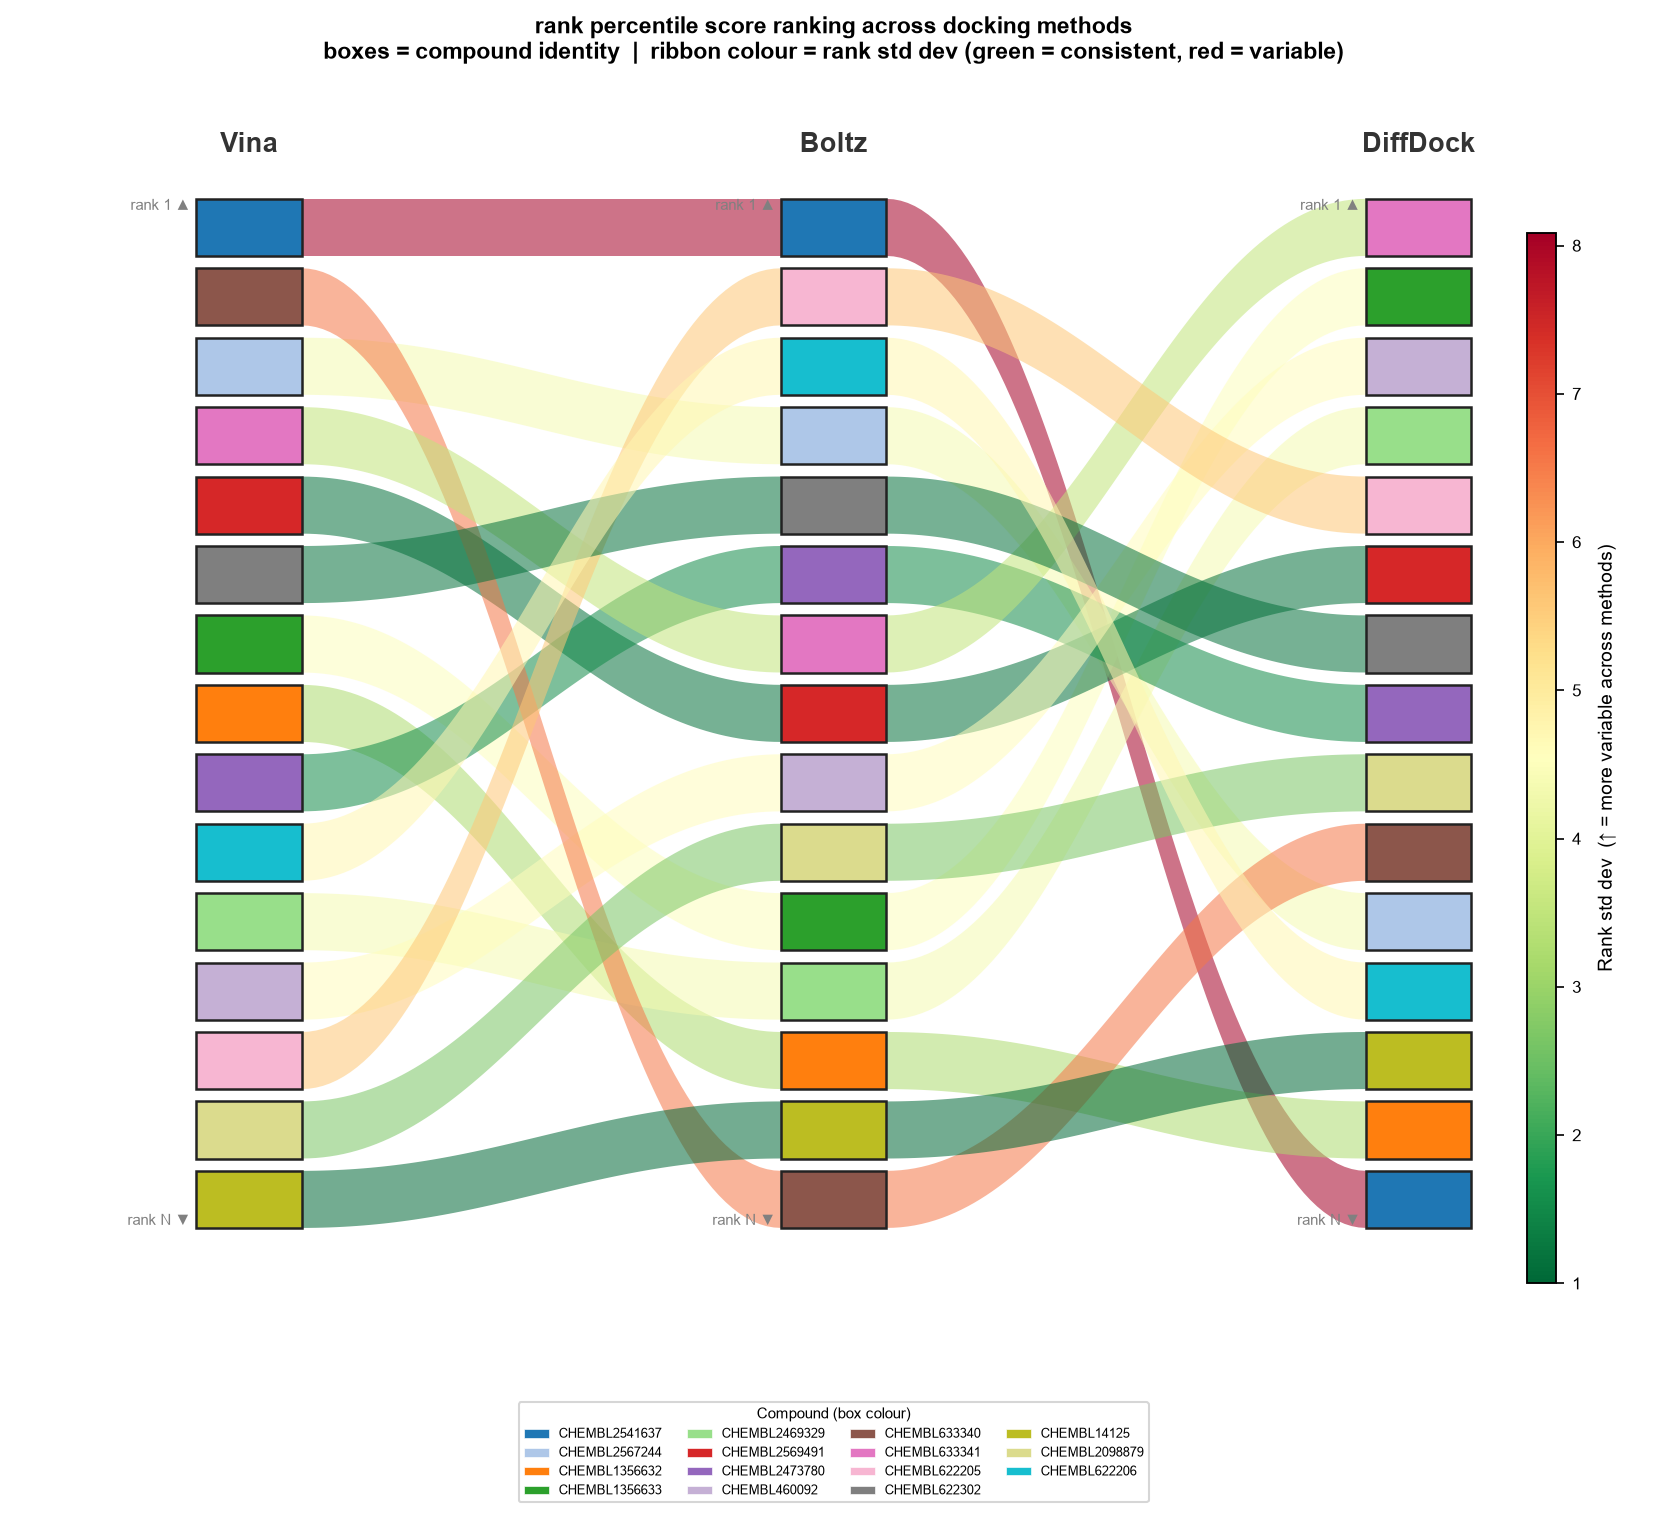

Saved: C:/Users/antonio/Desktop/guild_publication/review/figures_regenerated\guild_rank_alluvial.png


In [4]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ── Setup ─────────────────────────────────────────────────────────────────────
# Current-generation rank-percentile column names (rp_*), not the guild_* names this
# cell used to hardcode -- those never existed in the 3-target rerun (see
# notebooks/analysis/README.md's naming-generations table), which is why this cell used
# to fail partway through a top-to-bottom run. Each is that pose source's own
# rank-percentile column (not the Vina-rescore vote Figure 2 and Step 4 of the schematic
# use), matching what this alluvial plot originally compared.
GUILD_COLS = [
    ("Vina",     "rp_vina_score"),
    ("Boltz",    "rp_boltz_score"),
    ("DiffDock", "rp_diffdock_score"),
]
N_METHODS   = len(GUILD_COLS)
X_POSITIONS = np.array([0.0, 1.0, 2.0])
BOX_WIDTH   = 0.18
BOX_GAP     = 0.012

# ── Filter: non-decoys only ───────────────────────────────────────────────────
non_decoy = df[df["ligand_category"] != "decoy"].copy()
rp_score_cols = [c for _, c in GUILD_COLS]
non_decoy = non_decoy.dropna(subset=rp_score_cols, how="all").reset_index(drop=True)
n_compounds = len(non_decoy)
print(f"Non-decoy compounds: {n_compounds}")
print(non_decoy["ligand_category"].value_counts())

# ── One unique colour per compound (boxes) ───────────────────────────────────
cmap = plt.colormaps["tab20"].resampled(max(n_compounds, 20))
if n_compounds > 20:
    cmap = plt.colormaps["hsv"].resampled(n_compounds)
compound_colors = {
    row["ligand_id"]: mcolors.to_hex(cmap(i / n_compounds))
    for i, (_, row) in enumerate(non_decoy.iterrows())
}

# ── Rank std per compound (ribbon colour) ─────────────────────────────────────
# Measures how consistently a compound is ranked across the three methods.
# Low std = stable rank; high std = rank jumps wildly between methods.
rank_cols = []
for method, col in GUILD_COLS:
    non_decoy[f"rank_{method}"] = non_decoy[col].rank(method="first", ascending=True)
    rank_cols.append(f"rank_{method}")

non_decoy["rank_std"] = non_decoy[rank_cols].std(axis=1)
rank_std_max = non_decoy["rank_std"].max()
rank_std_min = non_decoy["rank_std"].min()

# RdYlGn_r: green = consistent, red = variable
ribbon_cmap = plt.colormaps["RdYlGn_r"]
def ribbon_color(lig_id):
    std = non_decoy.loc[non_decoy["ligand_id"] == lig_id, "rank_std"].values[0]
    t   = (std - rank_std_min) / (rank_std_max - rank_std_min + 1e-9)
    return ribbon_cmap(t)

# ── Per-layer sorted positions ────────────────────────────────────────────────
def layer_positions(col, total_height=1.0):
    sub   = non_decoy[["ligand_id", col]].dropna(subset=[col]).copy()
    sub   = sub.sort_values(col, ascending=True).reset_index(drop=True)
    n     = len(sub)
    box_h = (total_height - BOX_GAP * (n - 1)) / n
    positions = {}
    for rank, row in sub.iterrows():
        y_top    = total_height - rank * (box_h + BOX_GAP)
        y_centre = y_top - box_h / 2
        positions[row["ligand_id"]] = {"y_centre": y_centre, "box_h": box_h}
    return positions

TOTAL_H   = 1.0
layer_pos = {method: layer_positions(col) for method, col in GUILD_COLS}

# ── Bezier ribbon ─────────────────────────────────────────────────────────────
def ribbon(ax, x0, y0, x1, y1, h0, h1, color, alpha=0.4, n=80):
    t   = np.linspace(0, 1, n)
    cx0 = x0 + BOX_WIDTH / 2 + (x1 - x0 - BOX_WIDTH) * 0.4
    cx1 = x1 - BOX_WIDTH / 2 - (x1 - x0 - BOX_WIDTH) * 0.4

    top_by = (1-t)**3*(y0+h0/2) + 3*(1-t)**2*t*(y0+h0/2) + 3*(1-t)*t**2*(y1+h1/2) + t**3*(y1+h1/2)
    top_bx = (1-t)**3*(x0+BOX_WIDTH/2) + 3*(1-t)**2*t*cx0 + 3*(1-t)*t**2*cx1 + t**3*(x1-BOX_WIDTH/2)
    bot_by = (1-t)**3*(y0-h0/2) + 3*(1-t)**2*t*(y0-h0/2) + 3*(1-t)*t**2*(y1-h1/2) + t**3*(y1-h1/2)

    poly_x = np.concatenate([top_bx, top_bx[::-1]])
    poly_y = np.concatenate([top_by, bot_by[::-1]])
    ax.fill(poly_x, poly_y, color=color, alpha=alpha, linewidth=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 10), constrained_layout=True)

# Ribbons first (behind boxes) — coloured by rank std (green=consistent, red=variable)
for i in range(N_METHODS - 1):
    m_left,  _ = GUILD_COLS[i]
    m_right, _ = GUILD_COLS[i + 1]
    pos_left   = layer_pos[m_left]
    pos_right  = layer_pos[m_right]
    for lig_id in compound_colors:
        if lig_id not in pos_left or lig_id not in pos_right:
            continue
        p0 = pos_left[lig_id]
        p1 = pos_right[lig_id]
        ribbon(ax, X_POSITIONS[i], p0["y_centre"], X_POSITIONS[i+1], p1["y_centre"],
               p0["box_h"], p1["box_h"], color=ribbon_color(lig_id), alpha=0.55)

# Compound boxes on top
for col_idx, (method, col) in enumerate(GUILD_COLS):
    x = X_POSITIONS[col_idx]
    for lig_id, pinfo in layer_pos[method].items():
        color = compound_colors[lig_id]
        y_low = pinfo["y_centre"] - pinfo["box_h"] / 2
        rect  = mpatches.FancyBboxPatch(
            (x - BOX_WIDTH / 2, y_low), BOX_WIDTH, pinfo["box_h"],
            boxstyle="square,pad=0",
            facecolor=color, edgecolor="#222222", linewidth=1.2, zorder=3,
        )
        ax.add_patch(rect)

# ── Method labels (neutral dark colour) ──────────────────────────────────────
for xi, (method, _) in zip(X_POSITIONS, GUILD_COLS, strict=False):
    ax.text(xi, TOTAL_H + 0.04, method,
            ha="center", va="bottom", fontsize=13, fontweight="bold",
            color="#333333")
    ax.text(xi - BOX_WIDTH / 2 - 0.01, TOTAL_H,  "rank 1 ▲",
            ha="right", va="top",    fontsize=7, color="gray")
    ax.text(xi - BOX_WIDTH / 2 - 0.01, 0.0,       "rank N ▼",
            ha="right", va="bottom", fontsize=7, color="gray")

ax.set_xlim(-0.4, N_METHODS - 1 + 0.4)
ax.set_ylim(-0.06, TOTAL_H + 0.12)
ax.axis("off")

# ── Colorbar for rank std ─────────────────────────────────────────────────────
import matplotlib.cm as cm
from matplotlib.colors import Normalize

norm    = Normalize(vmin=rank_std_min, vmax=rank_std_max)
sm      = cm.ScalarMappable(cmap=ribbon_cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.018, 0.70])
cbar    = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Rank std dev  (↑ = more variable across methods)", fontsize=9, labelpad=8)
cbar.ax.tick_params(labelsize=8)

# ── Compound legend ───────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=compound_colors[row["ligand_id"]],
                   edgecolor="white", linewidth=0.3,
                   label=row["ligand_id"])
    for _, row in non_decoy.iterrows()
]
ax.legend(
    handles=handles, title="Compound (box colour)", fontsize=6, title_fontsize=7,
    loc="lower center", ncol=4, frameon=True,
    bbox_to_anchor=(0.5, -0.18),
)

ax.set_title(
    "rank percentile score ranking across docking methods\n"
    "boxes = compound identity  |  ribbon colour = rank std dev (green = consistent, red = variable)",
    fontsize=11, fontweight="bold", pad=8,
)

out = os.path.join(OUT_DIR, "guild_rank_alluvial.png")
fig.savefig(out, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Guild rank alluvial — v1 (compound-coloured ribbons)

Same layout as above but ribbons carry the **compound colour** rather than the rank-std encoding,
so you can follow each compound visually across methods without the variability signal.
Saved as `guild_rank_alluvial_v1.png`.


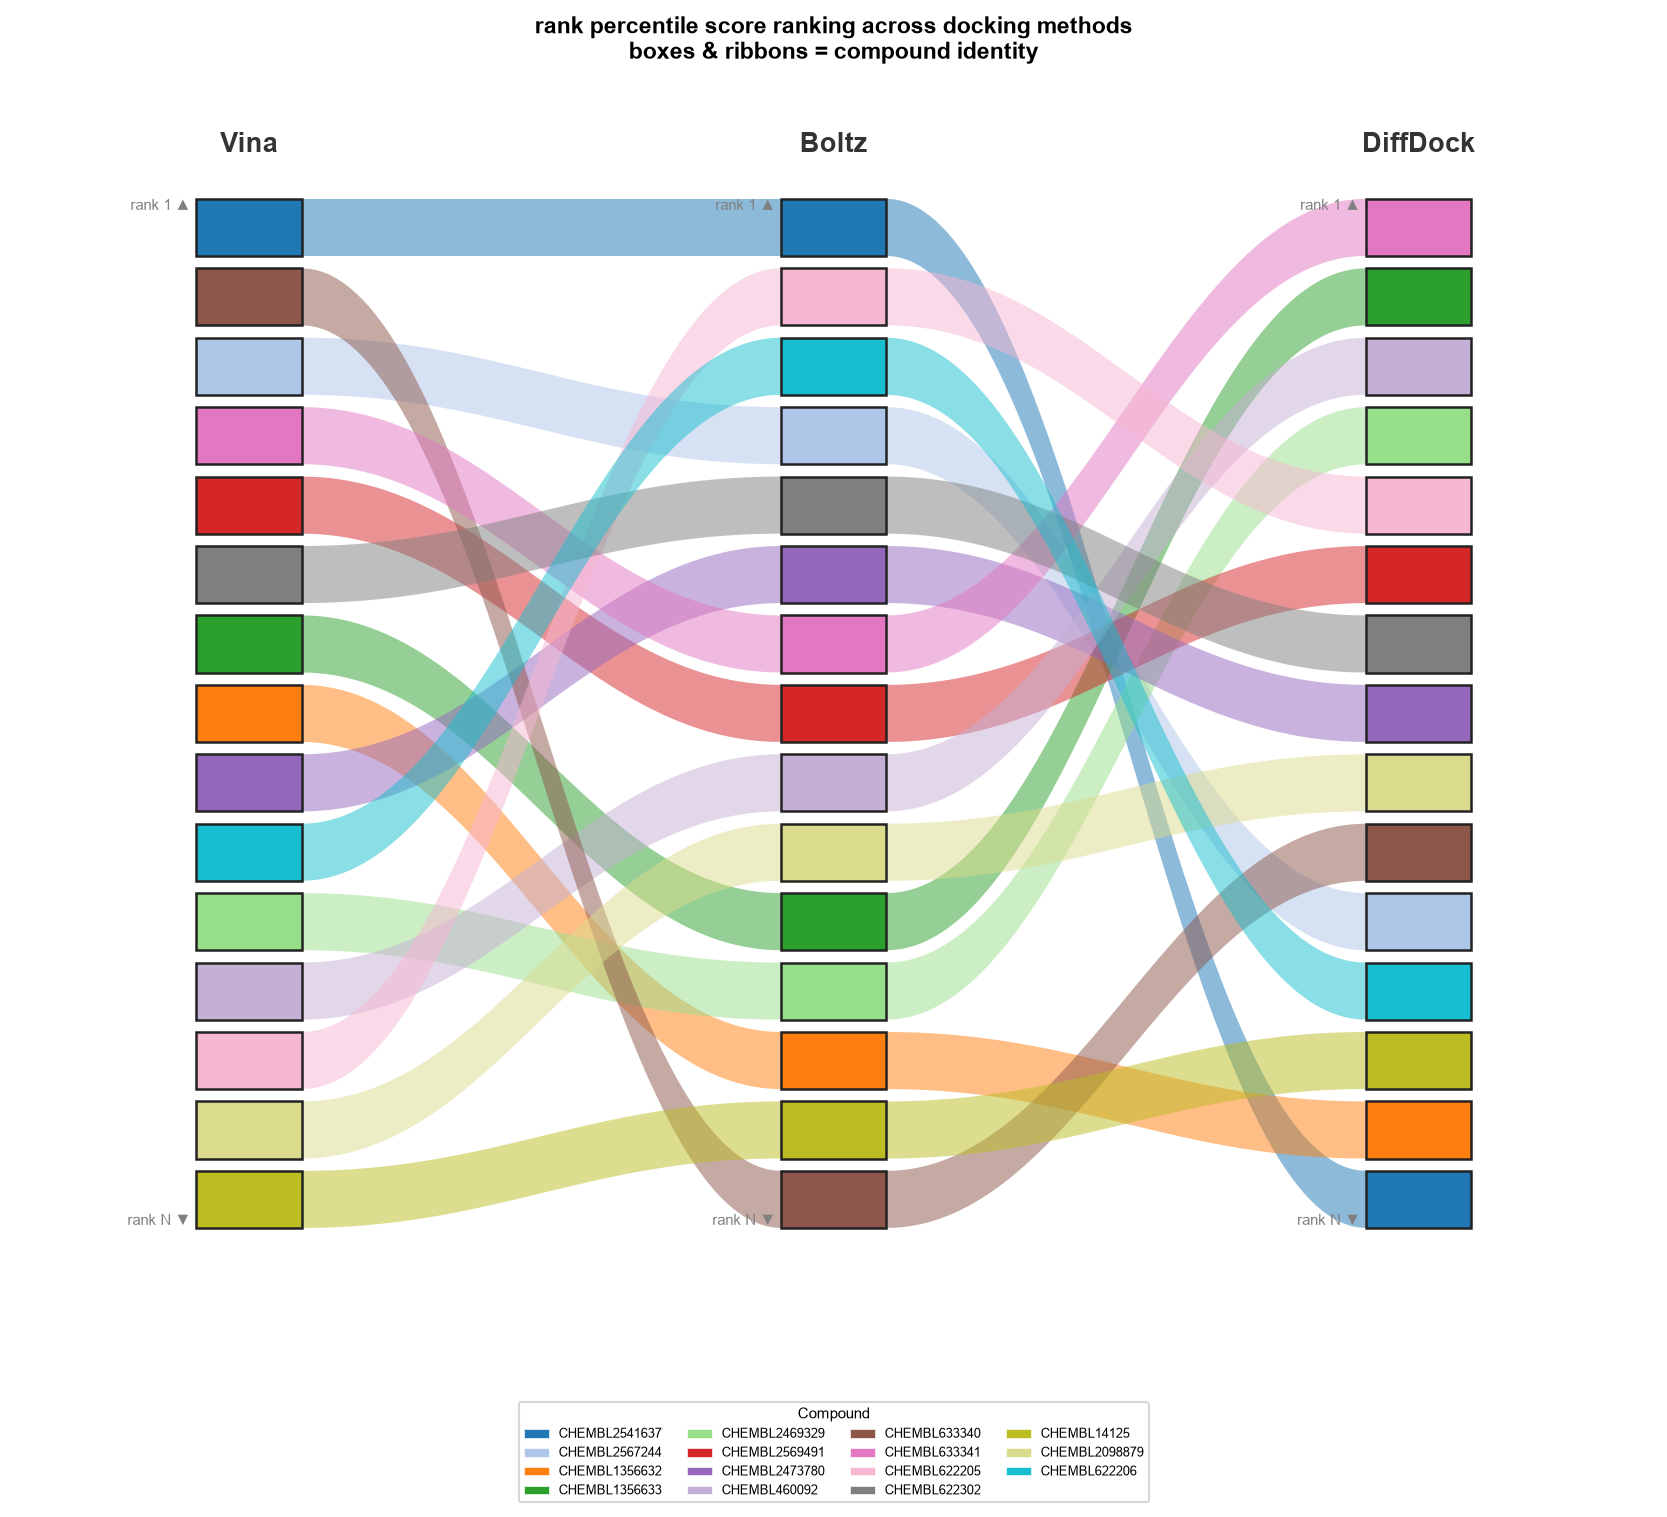

Saved: C:/Users/antonio/Desktop/guild_publication/review/figures_regenerated\guild_rank_alluvial_v1.png


In [5]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ── Reuse configuration from the rank-std cell ────────────────────────────────
# GUILD_COLS, X_POSITIONS, BOX_WIDTH, BOX_GAP, TOTAL_H, n_compounds,
# compound_colors, layer_pos, ribbon() are all still in scope.

def ribbon_v1(ax, x0, y0, x1, y1, h0, h1, color, alpha=0.4, n=80):
    """Bezier ribbon with a uniform compound colour."""
    t   = np.linspace(0, 1, n)
    cx0 = x0 + BOX_WIDTH / 2 + (x1 - x0 - BOX_WIDTH) * 0.4
    cx1 = x1 - BOX_WIDTH / 2 - (x1 - x0 - BOX_WIDTH) * 0.4

    top_by = (1-t)**3*(y0+h0/2) + 3*(1-t)**2*t*(y0+h0/2) + 3*(1-t)*t**2*(y1+h1/2) + t**3*(y1+h1/2)
    top_bx = (1-t)**3*(x0+BOX_WIDTH/2) + 3*(1-t)**2*t*cx0 + 3*(1-t)*t**2*cx1 + t**3*(x1-BOX_WIDTH/2)
    bot_by = (1-t)**3*(y0-h0/2) + 3*(1-t)**2*t*(y0-h0/2) + 3*(1-t)*t**2*(y1-h1/2) + t**3*(y1-h1/2)

    poly_x = np.concatenate([top_bx, top_bx[::-1]])
    poly_y = np.concatenate([top_by, bot_by[::-1]])
    ax.fill(poly_x, poly_y, color=color, alpha=alpha, linewidth=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig_v1, ax_v1 = plt.subplots(figsize=(11, 10), constrained_layout=True)

# Ribbons first — coloured by compound identity
for i in range(N_METHODS - 1):
    m_left,  _ = GUILD_COLS[i]
    m_right, _ = GUILD_COLS[i + 1]
    pos_left   = layer_pos[m_left]
    pos_right  = layer_pos[m_right]
    for lig_id in compound_colors:
        if lig_id not in pos_left or lig_id not in pos_right:
            continue
        p0 = pos_left[lig_id]
        p1 = pos_right[lig_id]
        ribbon_v1(ax_v1, X_POSITIONS[i], p0["y_centre"], X_POSITIONS[i+1], p1["y_centre"],
                  p0["box_h"], p1["box_h"], color=compound_colors[lig_id], alpha=0.50)

# Compound boxes on top
for col_idx, (method, col) in enumerate(GUILD_COLS):
    x = X_POSITIONS[col_idx]
    for lig_id, pinfo in layer_pos[method].items():
        color = compound_colors[lig_id]
        y_low = pinfo["y_centre"] - pinfo["box_h"] / 2
        rect  = mpatches.FancyBboxPatch(
            (x - BOX_WIDTH / 2, y_low), BOX_WIDTH, pinfo["box_h"],
            boxstyle="square,pad=0",
            facecolor=color, edgecolor="#222222", linewidth=1.2, zorder=3,
        )
        ax_v1.add_patch(rect)

# Method labels
for xi, (method, _) in zip(X_POSITIONS, GUILD_COLS, strict=False):
    ax_v1.text(xi, TOTAL_H + 0.04, method,
               ha="center", va="bottom", fontsize=13, fontweight="bold",
               color="#333333")
    ax_v1.text(xi - BOX_WIDTH / 2 - 0.01, TOTAL_H,  "rank 1 ▲",
               ha="right", va="top",    fontsize=7, color="gray")
    ax_v1.text(xi - BOX_WIDTH / 2 - 0.01, 0.0,       "rank N ▼",
               ha="right", va="bottom", fontsize=7, color="gray")

ax_v1.set_xlim(-0.4, N_METHODS - 1 + 0.4)
ax_v1.set_ylim(-0.06, TOTAL_H + 0.12)
ax_v1.axis("off")

# ── Compound legend ───────────────────────────────────────────────────────────
handles_v1 = [
    mpatches.Patch(facecolor=compound_colors[row["ligand_id"]],
                   edgecolor="white", linewidth=0.3,
                   label=row["ligand_id"])
    for _, row in non_decoy.iterrows()
]
ax_v1.legend(
    handles=handles_v1, title="Compound", fontsize=6, title_fontsize=7,
    loc="lower center", ncol=4, frameon=True,
    bbox_to_anchor=(0.5, -0.18),
)

ax_v1.set_title(
    "rank percentile score ranking across docking methods\n"
    "boxes & ribbons = compound identity",
    fontsize=11, fontweight="bold", pad=8,
)

out_v1 = os.path.join(OUT_DIR, "guild_rank_alluvial_v1.png")
fig_v1.savefig(out_v1, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_v1}")


## Composite panel figures

Two multi-panel figures combining the score-distribution plot with each Sankey variant.
- **Panel A** — distributions + Sankey v1 (compound-coloured ribbons) → `guild_panel_v1.png`
- **Panel B** — distributions + Sankey v2 (rank-std ribbon colour) → `guild_panel_v2.png`


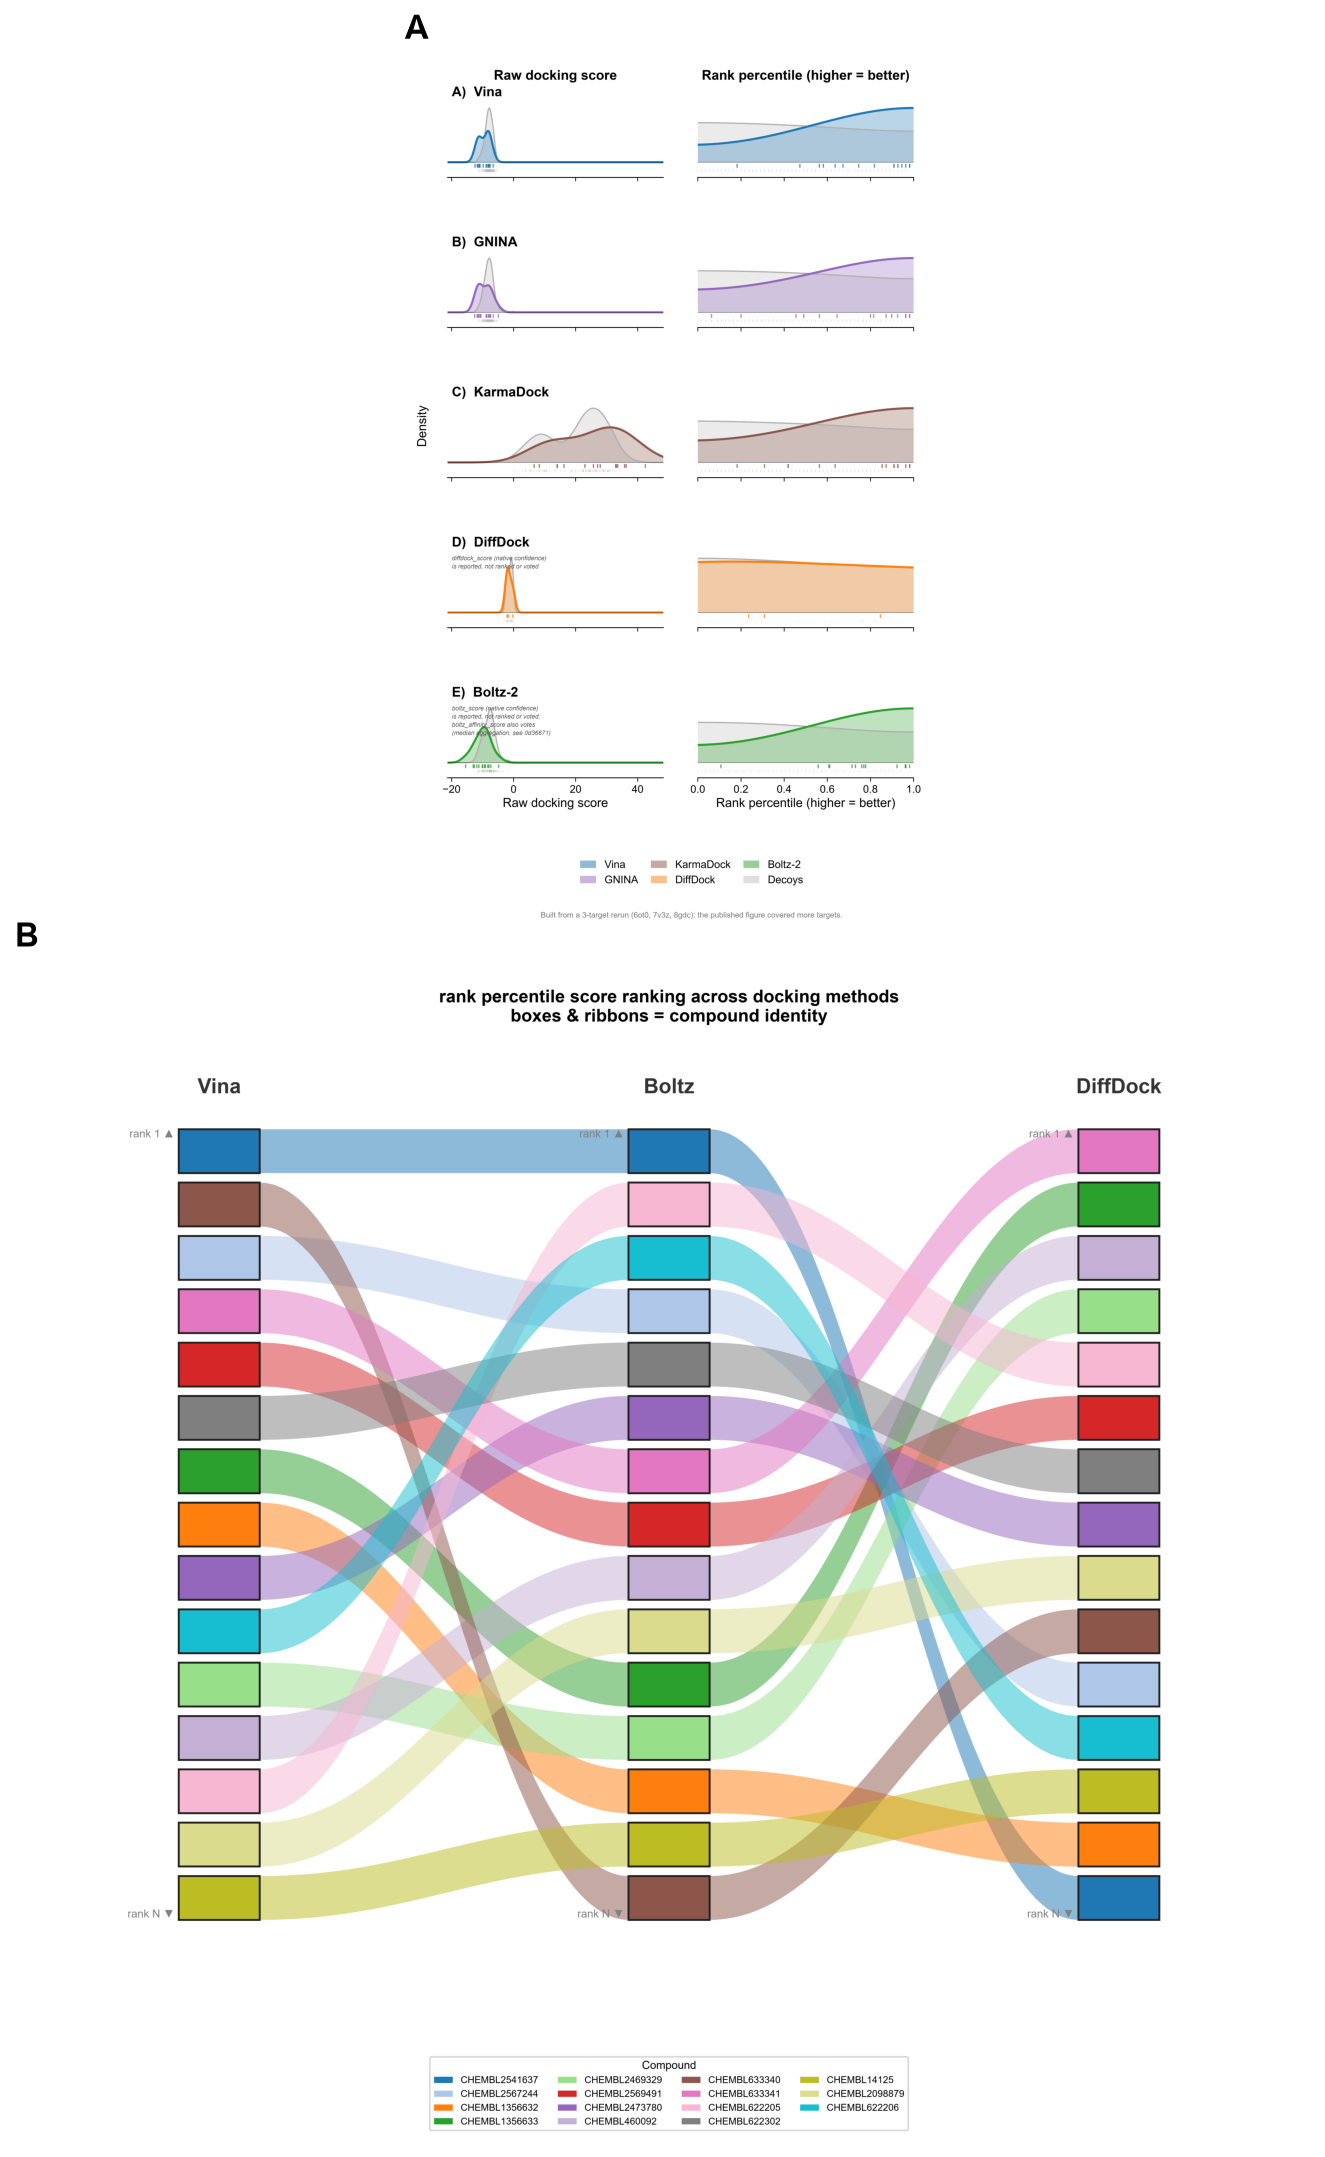

Saved panel v1 (compound ribbons): C:/Users/antonio/Desktop/guild_publication/review/figures_regenerated\guild_panel_v1.png


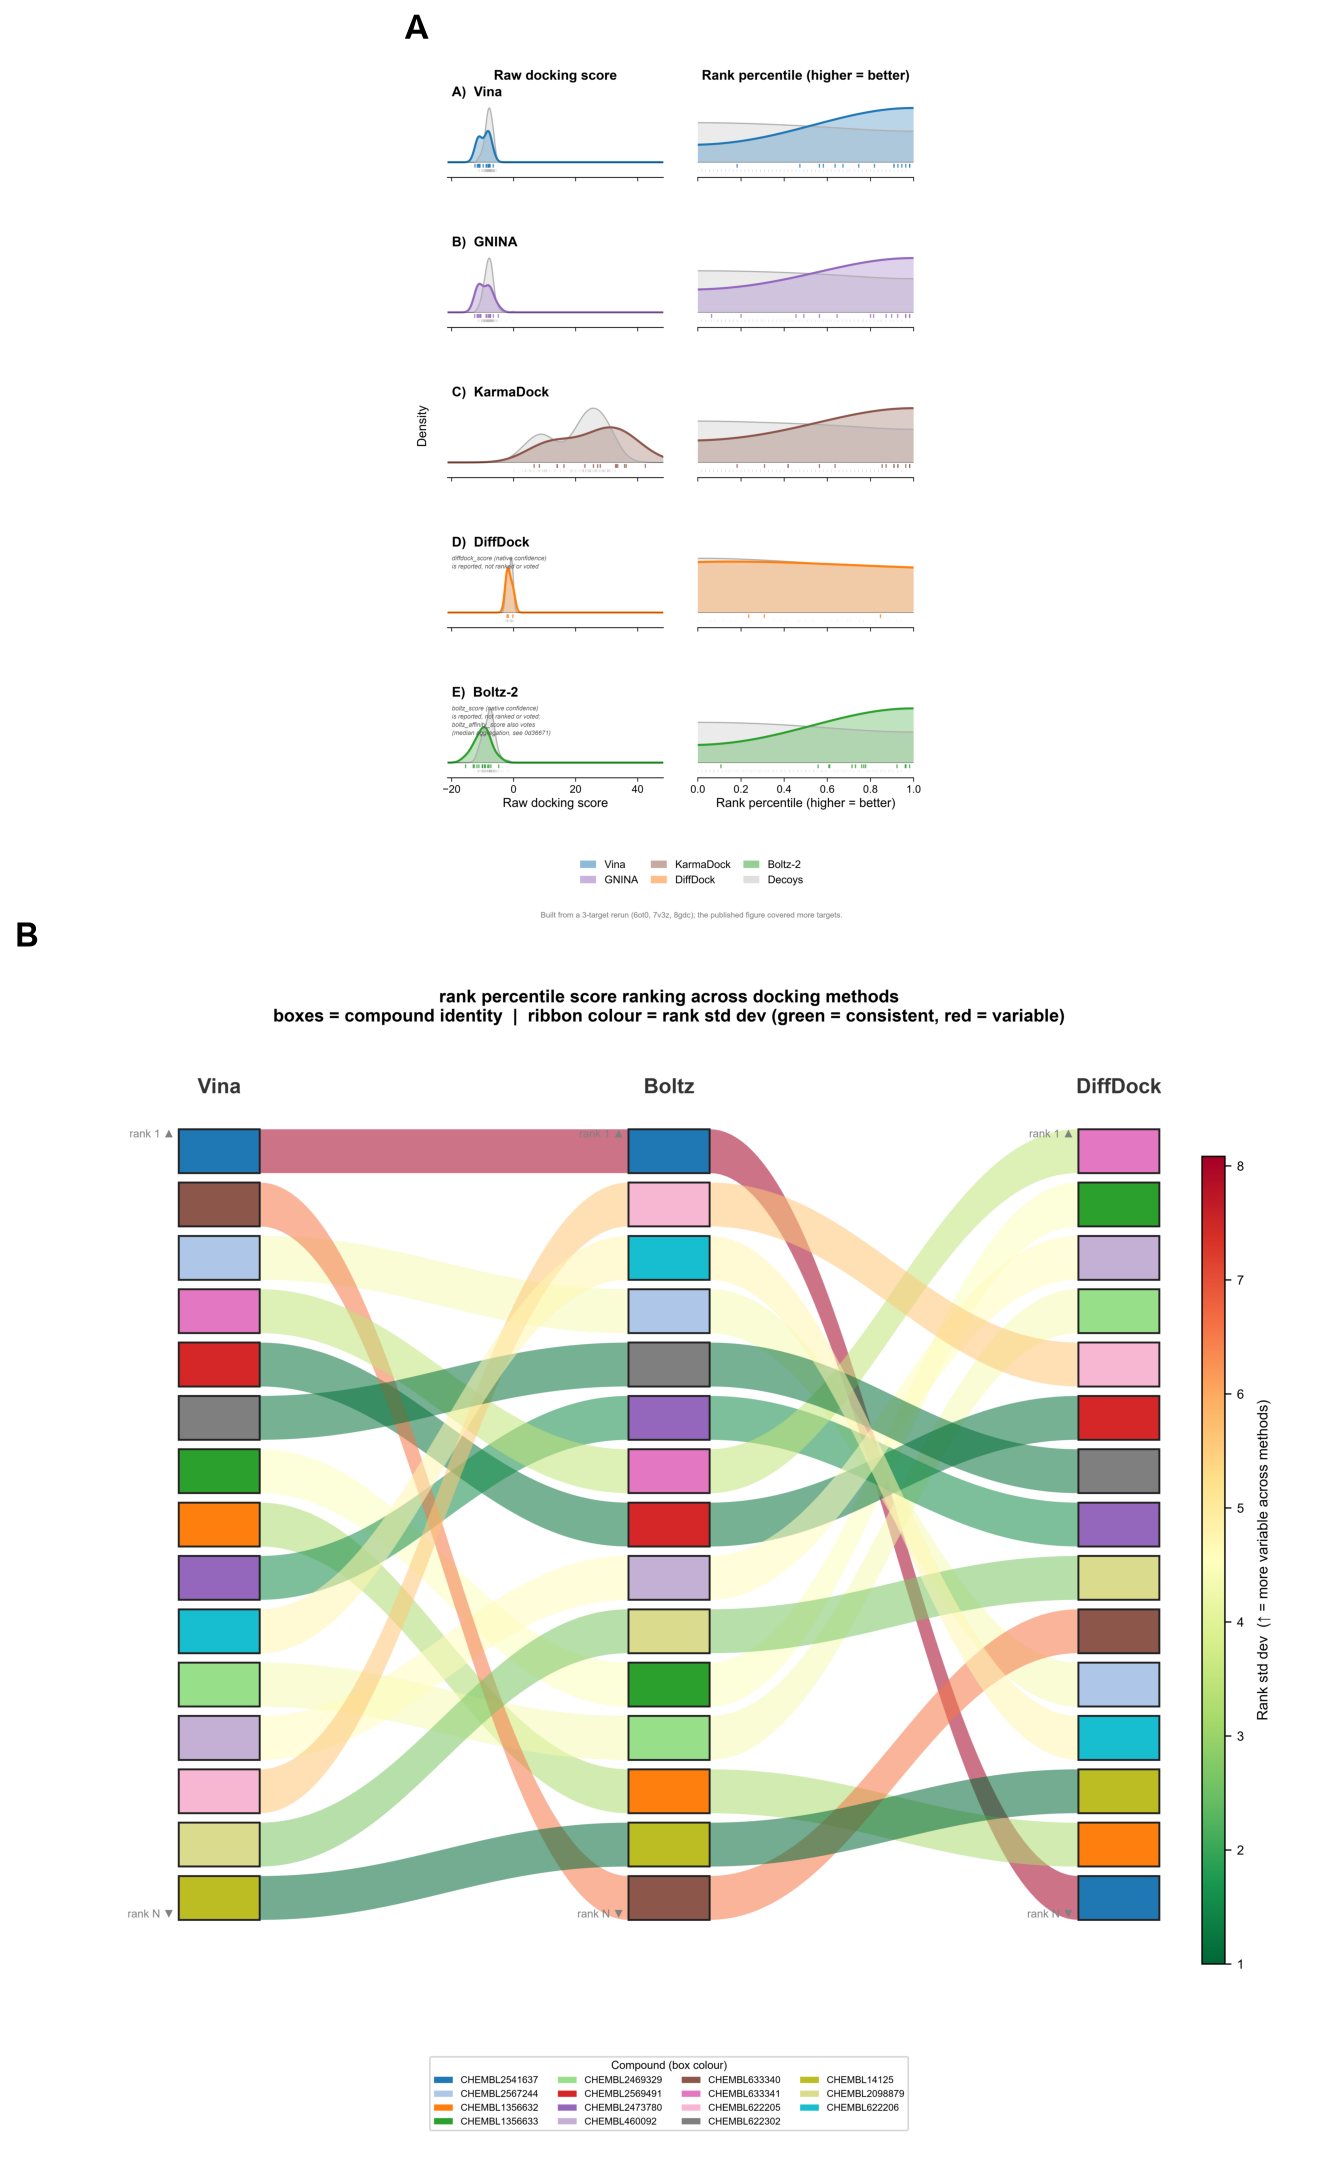

Saved panel v2 (rank-std ribbons): C:/Users/antonio/Desktop/guild_publication/review/figures_regenerated\guild_panel_v2.png


In [6]:
def make_panel(dist_path, sankey_path, out_path, panel_tag):
    """
    Composite: distributions on top (A), Sankey below (B).
    Both are loaded from saved PNGs so this cell is independent of figure state.
    """
    dist_img   = plt.imread(dist_path)
    sankey_img = plt.imread(sankey_path)

    # Height ratios derived from source figure sizes (distributions 8 in, Sankey 10 in)
    fig_p = plt.figure(figsize=(16, 18), constrained_layout=False)
    gs = fig_p.add_gridspec(2, 1, height_ratios=[1, 1.35], hspace=0.05)

    ax_dist   = fig_p.add_subplot(gs[0])
    ax_sankey = fig_p.add_subplot(gs[1])

    for ax_img, img in [(ax_dist, dist_img), (ax_sankey, sankey_img)]:
        ax_img.imshow(img)
        ax_img.set_axis_off()

    # Panel tags top-left
    for ax_img, tag in [(ax_dist, "A"), (ax_sankey, "B")]:
        ax_img.text(-0.01, 1.02, tag,
                    transform=ax_img.transAxes,
                    fontsize=16, fontweight="bold", va="bottom", ha="left")

    out_p = os.path.join(OUT_DIR, out_path)
    fig_p.savefig(out_p, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved panel {panel_tag}: {out_p}")


dist_png      = os.path.join(OUT_DIR, "figure_2_score_distributions.png")
sankey_v1_png = os.path.join(OUT_DIR, "guild_rank_alluvial_v1.png")
sankey_v2_png = os.path.join(OUT_DIR, "guild_rank_alluvial.png")

make_panel(dist_png, sankey_v1_png, "guild_panel_v1.png", "v1 (compound ribbons)")
make_panel(dist_png, sankey_v2_png, "guild_panel_v2.png", "v2 (rank-std ribbons)")